In [33]:
# 1. Imports
import pandas as pd
import torch
from sklearn.metrics import r2_score

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error

In [34]:
# Load dataset and keep only necessary columns
df = pd.read_csv("../dataset/BTC_Tweets_Updated.csv")
df = df[['Tweet', 'New_Sentiment_Score']].dropna().head(1000)

# Ensure score is float for regression
df['New_Sentiment_Score'] = df['New_Sentiment_Score'].astype(float)
print(df['New_Sentiment_Score'].describe())


count    1000.000000
mean        0.087987
std         0.209308
min        -0.800000
25%         0.000000
50%         0.000000
75%         0.143750
max         0.910000
Name: New_Sentiment_Score, dtype: float64


In [35]:
# Train/test split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Tweet'].tolist(), df['New_Sentiment_Score'].tolist(), test_size=0.2, random_state=42
)

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)


In [36]:
# Custom Dataset for Regression
class SentimentRegressionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

# Loaders
train_dataset = SentimentRegressionDataset(train_encodings, train_labels)
val_dataset = SentimentRegressionDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


In [37]:
# Model setup for regression
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = BertConfig.from_pretrained("bert-base-uncased", num_labels=1)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", config=config)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
# Training loop
model.train()
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for step, batch in enumerate(progress_bar):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        progress_bar.set_postfix(batch_loss=loss.item())

    print(f"Epoch {epoch + 1} completed. Total loss: {total_loss:.4f}")


Epoch 1/10


Epoch 1 completed. Total loss: 2.9918

Epoch 2/10


Epoch 2 completed. Total loss: 1.7731

Epoch 3/10


Epoch 3 completed. Total loss: 1.0375

Epoch 4/10


Epoch 4 completed. Total loss: 0.6188

Epoch 5/10


...

Epoch 6 completed. Total loss: 0.3967

Epoch 7/10


Epoch 7 completed. Total loss: 0.2949

Epoch 8/10


Epoch 8 completed. Total loss: 0.2910

Epoch 9/10


Epoch 9 completed. Total loss: 0.2369

Epoch 10/10


Epoch 10 completed. Total loss: 0.2574


In [39]:
model.eval()
preds = []
true_vals = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits.squeeze().cpu().numpy()
        labels = batch['labels'].cpu().numpy()
        preds.extend(logits.tolist())
        true_vals.extend(labels.tolist())


mae = mean_absolute_error(true_vals, preds)

r2 = r2_score(true_vals, preds)
mse = mean_squared_error(true_vals, preds)
print(f"\nMean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
# Print a few sample predictions
for i in range(5):
    print(f"True: {true_vals[i]:.3f} | Predicted: {preds[i]:.3f}")



Mean Squared Error: 0.0120
Mean Absolute Error: 0.0721
R² Score: 0.7317
True: 0.000 | Predicted: 0.335
True: 0.000 | Predicted: 0.019
True: 0.000 | Predicted: 0.008
True: 0.000 | Predicted: -0.017
True: 0.068 | Predicted: 0.100


In [40]:
# Save model and tokenizer
model_save_path = "./bert_sentiment_regression_model"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model and tokenizer saved to {model_save_path}")


Model and tokenizer saved to ./bert_sentiment_regression_model


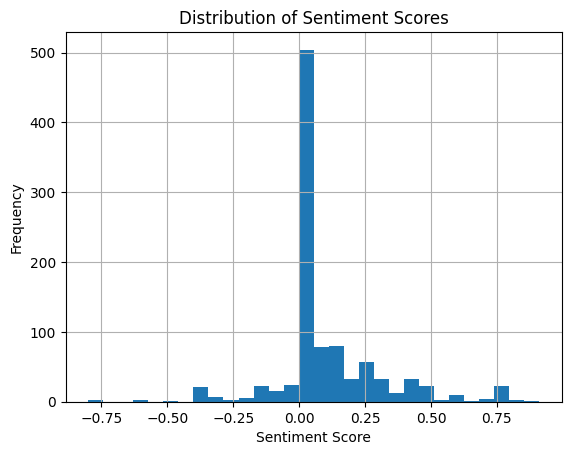

In [42]:
import matplotlib.pyplot as plt
df['New_Sentiment_Score'].hist(bins=30)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()